Johanna Andrea Morales Rodriguez

# SMS Spam Collection

**Dataset:** https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset?resource=download


# Objetivo principal:

- Detectar si un SMS es spam (no deseado) o ham (legítimo).

# Origen de los datos:

- Mensajes SMS reales recolectados de fuentes públicas.

- Etiquetados manualmente como spam o ham.

---


# Componentes del Análisis

# 1. Exploración de Datos

- Análisis Univariante
- Análisis Bivariante
- Matriz de Correlaciones
- Conteo Cruzado

# 2. Visualizaciones Incluidas

- Histogramas de distribuciones
- Box plots (diagramas de cajas y bigotes)
- Scatter plots (diagramas de dispersión)
- Heatmaps de correlación y contingencia
- Gráficos de barras comparativos

# 3. Preparación de Datos

- Selección de características
- Tratamiento de texto
- Creación de variables derivadas
- División estratificada de datos

# 4. Modelación

- Algoritmos incluidos: Naive Bayes, Random Forest, Decision Tree, Logistic Regression
- Búsqueda de hiperparámetros
- Integración con PyCaret para comparación automática

# 5. Evaluación Completa

- Matrices de confusión
- Classification report
- Métricas: Accuracy, Precision, Recall, F1-Score
- Justificación detallada del modelo seleccionado

In [1]:
# Imports y librerias
#Uso de datos
import numpy as np
import pandas as pd
import statsmodels.api as sm

#Gráficos
import matplotlib.pyplot as plt
import seaborn as sb
import plotly.express as px
from matplotlib import cm

from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Patch
from scipy.stats import chi2_contingency, norm


#Preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split


from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from statsmodels.formula.api import ols

#Modelado y evaluación
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, classification_report, r2_score, mean_absolute_percentage_error, root_mean_squared_error, mean_absolute_error

#Advertencias
import warnings
warnings.filterwarnings('ignore')

# Preparacion de los datos

In [ ]:
# Carga de datos

# Se utilizo el formato: latin1 para evitar errores de decodificacion ya que el archivo contine caracteres especiales
df = pd.read_csv('spam.csv', encoding='latin1')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [ ]:
# Validamos que variables tienen datos nulos

df.isnull()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,False,False,True,True,True
1,False,False,True,True,True
2,False,False,True,True,True
3,False,False,True,True,True
4,False,False,True,True,True
...,...,...,...,...,...
5567,False,False,True,True,True
5568,False,False,True,True,True
5569,False,False,True,True,True
5570,False,False,True,True,True


In [ ]:
# Cuantos datos nulos hay por variable
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

<Axes: >

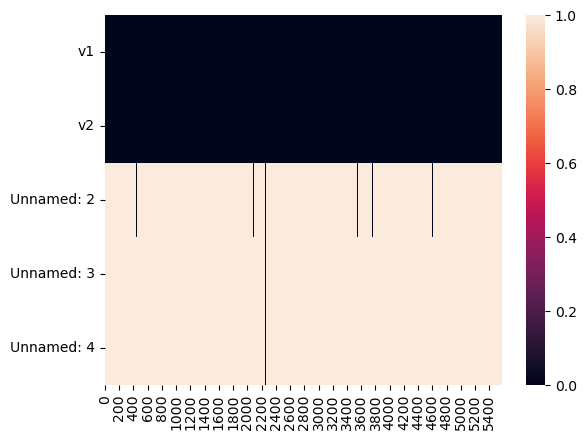

In [ ]:
# Grafico de concurrencia de datos nulos

df.isnull().transpose().pipe(lambda df: (sb.heatmap(data =df)))

In [ ]:
# Seleccionar columnas relevantes
df_clean = df[['v1', 'v2']]

# Renombrar columnas
df_clean .columns = ['category', 'message']
df_clean

,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
# Validamos que tipos de datos son las variables de nuestro conjunto de datos

df_clean.dtypes

category    object
message     object
dtype: object

In [ ]:
# Validamos que variables tenemos por tipo de dato

df_clean.dtypes.value_counts()

object    2
Name: count, dtype: int64

In [ ]:
# Primeras 5 filas

df_clean.head()

,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Información del dataset:

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  5572 non-null   object
 1   message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
# Validamos si con estos datos hay todavia nulos

df_clean.isnull()
df_clean.isnull().any()

category    False
message     False
dtype: bool

<Axes: >

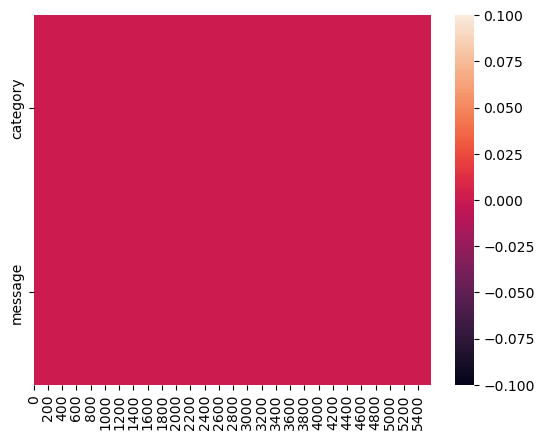

In [ ]:
# Grafico de concurrencia de datos nulos

df_clean.isnull().transpose().pipe(lambda df_clean: (sb.heatmap(data =df_clean)))

# Exploracion de los datos

# Analisis Univariado

Comportamientos estadisticos de las variables de forma unica

In [ ]:
df_clean.describe(include = 'all').transpose()

,count,unique,top,freq
category,5572,2,ham,4825
message,5572,5169,"Sorry, I'll call later",30


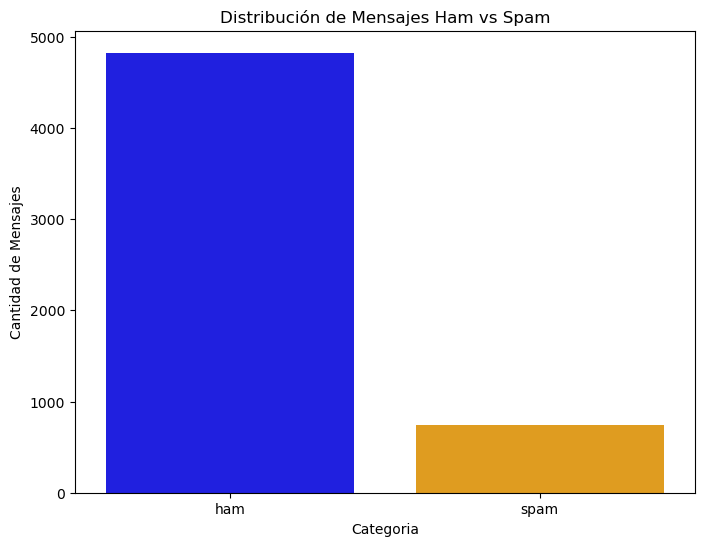

category
ham     86.593683
spam    13.406317
Name: count, dtype: float64


In [ ]:
# Conteo de mensajes por categoría
category_counts = df_clean['category'].value_counts()

plt.figure(figsize=(8,6))
sb.barplot(x=category_counts.index, y=category_counts.values, palette={"ham": "blue", "spam": "orange"})
plt.title('Distribución de Mensajes Ham vs Spam')
plt.xlabel('Categoria')
plt.ylabel('Cantidad de Mensajes')
plt.show()

# Porcentaje
print(category_counts / len(df) * 100)


In [ ]:
# df_clean['message_length'] contiene la longitud de cada mensaje en caracteres.
df_clean['message_length'] = df_clean['message'].apply(len)
df_clean['message_length']

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: message_length, Length: 5572, dtype: int64

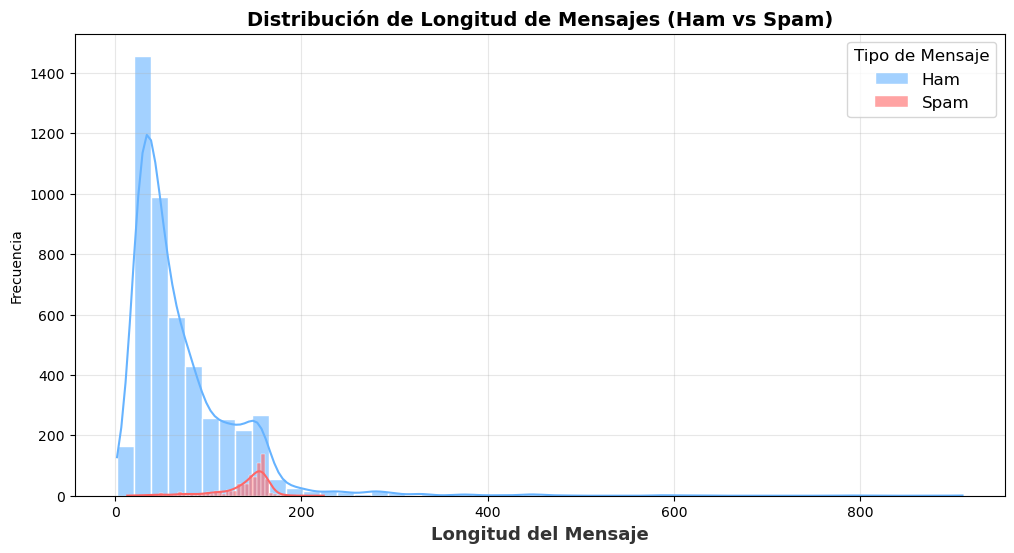

In [ ]:
# Visualization

plt.figure(figsize=(12,6))

# Plot histograms for ham and spam with pastel blue and red colors
# Histograma para mensajes ham
sb.histplot(
    data=df_clean[df_clean['category'] == 'ham'],
    x='message_length',
    color="#66b3ff",
    label='Ham',
    kde=True,
    edgecolor='white',
    alpha=0.6,
    bins=50
)

# Histograma para mensajes spam
sb.histplot(
    data=df_clean[df_clean['category'] == 'spam'],
    x='message_length',
    color="#ff6666",
    label='Spam',
    kde=True,
    edgecolor='white',
    alpha=0.6,
    bins=50
)

plt.title('Distribución de Longitud de Mensajes (Ham vs Spam)', fontsize=14, fontweight='bold')
plt.xlabel('Longitud del Mensaje', fontsize=13, fontweight='bold', color="#333333")
plt.ylabel('Frecuencia')
plt.legend(title="Tipo de Mensaje", title_fontsize=12, fontsize=12)
plt.grid(alpha=0.3)


# Mostrar gráfico

plt.show()

In [ ]:
# Obtener las estadísticas descriptivas

#stats_table = df_clean['message_length'].describe().round(0).to_frame(name='Estadísticas')
stats_table = df_clean['message_length'].describe().astype(int).to_frame(name='Estadísticas')
stats_table


,Estadísticas
count,5572
mean,80
std,59
min,2
25%,36
50%,61
75%,121
max,910


# Analisis Bivariado

- Ver la relación entre dos variables

Variable 1: category (tipo de mensaje: 'ham' o 'spam')

Variable 2: message_length (longitud del mensaje)

# Nota:
Este analisis nos permite comparar como varia la longitud de los mensajes dependiendo de si son spam o ham.

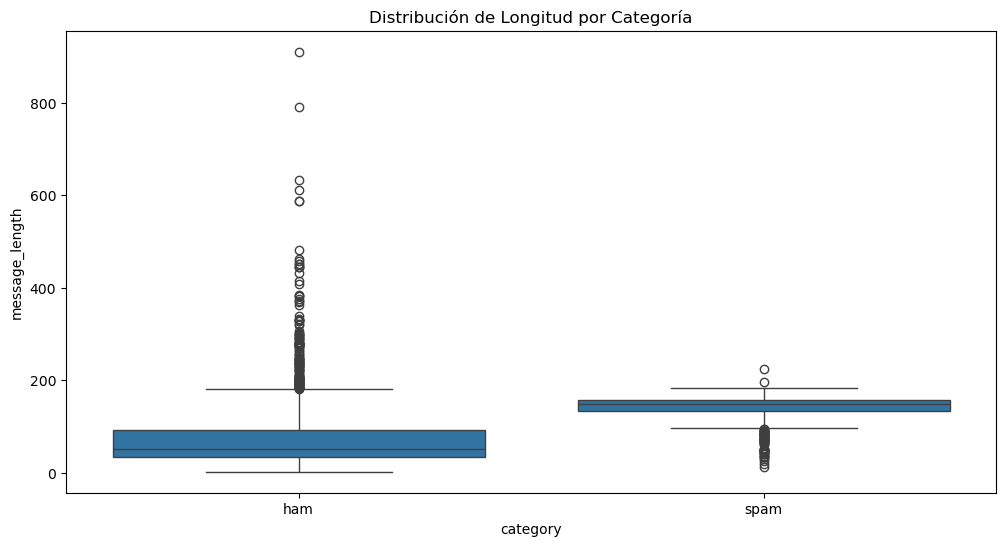

In [ ]:
# Longitud de mensajes por categoría

plt.figure(figsize=(12,6))
sb.boxplot(x='category', y='message_length', data=df_clean)
plt.title('Distribución de Longitud por Categoría')
plt.show()

In [ ]:
# Estadísticas descriptivas de message_length para cada grupo.
print(df_clean.groupby('category')['message_length'].describe())

           count        mean        std   min    25%    50%    75%    max
category                                                                 
ham       4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0
spam       747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0


# Ingenieria de caracteristicas

# Caracteristicas creadas
message_length: derivada de message → cantidad de caracteres.

word_count: número de palabras por mensaje.

special_chars: número de caracteres especiales (!@#$%, etc.).

uppercase_ratio: proporción de letras en mayúscula.

has_numbers: flag binario si el mensaje contiene números.

In [ ]:
# Crear caracteristicas numericas
df_clean['message_length'] = df_clean['message'].apply(len)
df_clean['has_links'] = df_clean['message'].str.contains('http|www|.com|.net|.org').astype(int)
df_clean['has_numbers'] = df_clean['message'].str.contains('\d').astype(int)
df_clean['uppercase_ratio'] = df_clean['message'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
df_clean['special_chars'] = df_clean['message'].apply(lambda x: sum(1 for c in x if not c.isalnum() and not c.isspace()))
df_clean['is_spam'] = df_clean['category'].map({'ham': 0, 'spam': 1})  # Variable objetivo numérica

# Graficos de dispersion (scatter plots)

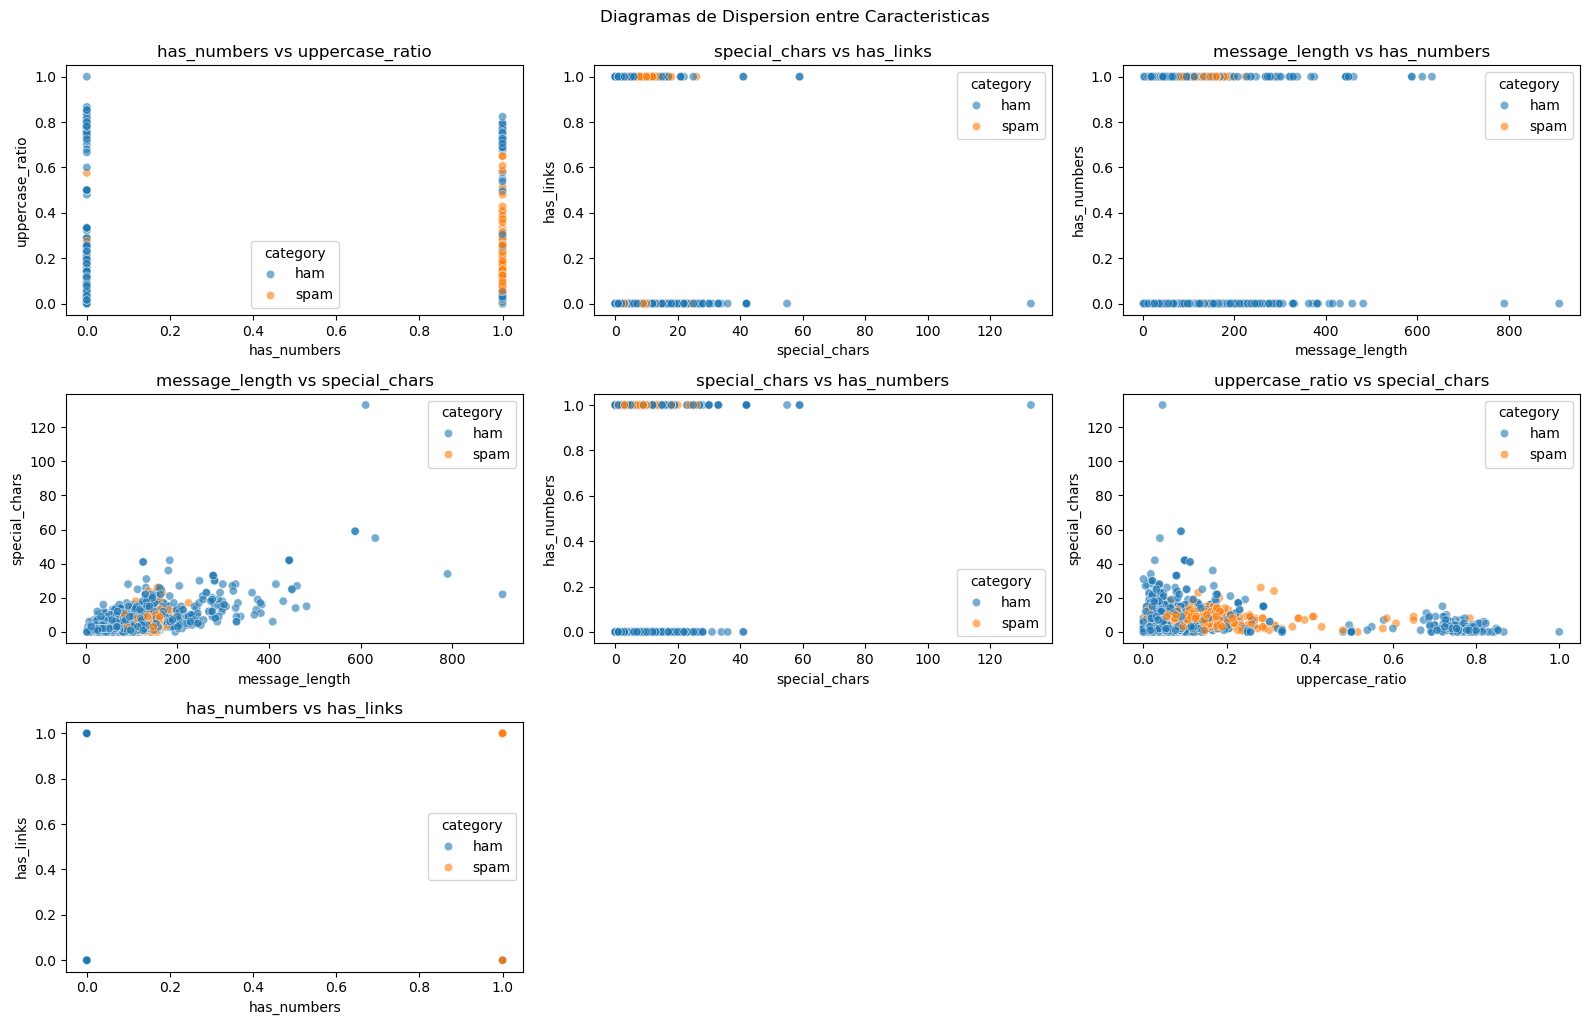

In [ ]:
# Crear pares de caracteristicas para scatter plots

# ¿Que tan relacionada está cada característica con la longitud del mensaje? Por esta razon se creara todos los pares de caracteristicas fueran con message_length.
# feature_pairs = [('message_length', 'has_links'),
                #('message_length', 'special_chars'),
                #('message_length', 'uppercase_ratio'),
                #('message_length', 'has_numbers')]
# Mejores pares
feature_pairs = [
    ('has_numbers', 'uppercase_ratio'),
    ('special_chars', 'has_links'),
    ('message_length', 'has_numbers'),
    ('message_length', 'special_chars'),
    ('special_chars', 'has_numbers'),
    ('uppercase_ratio', 'special_chars'),
    ('has_numbers', 'has_links'),
]
plt.figure(figsize=(16, 10))
for i, (x_feat, y_feat) in enumerate(feature_pairs, 1):
    plt.subplot(3, 3, i)
    sb.scatterplot(data=df_clean, x=x_feat, y=y_feat, hue='category', alpha=0.6)
    plt.title(f'{x_feat} vs {y_feat}')
    plt.xlabel(x_feat)
    plt.ylabel(y_feat)

plt.tight_layout()
plt.suptitle('Diagramas de Dispersion entre Caracteristicas', y=1.02)
plt.show()

# Diagramas de Caja y Bigotes por Categoría (Ham/Spam)

- Se mostrarán como se distribuyen las características numéricas en cada categoría (ham/spam)

**Nota:** Los mensajes spam suelen ser más largos, contener más números y caracteres especiales

In [ ]:
# Seleccionar solo columnas numéricas
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

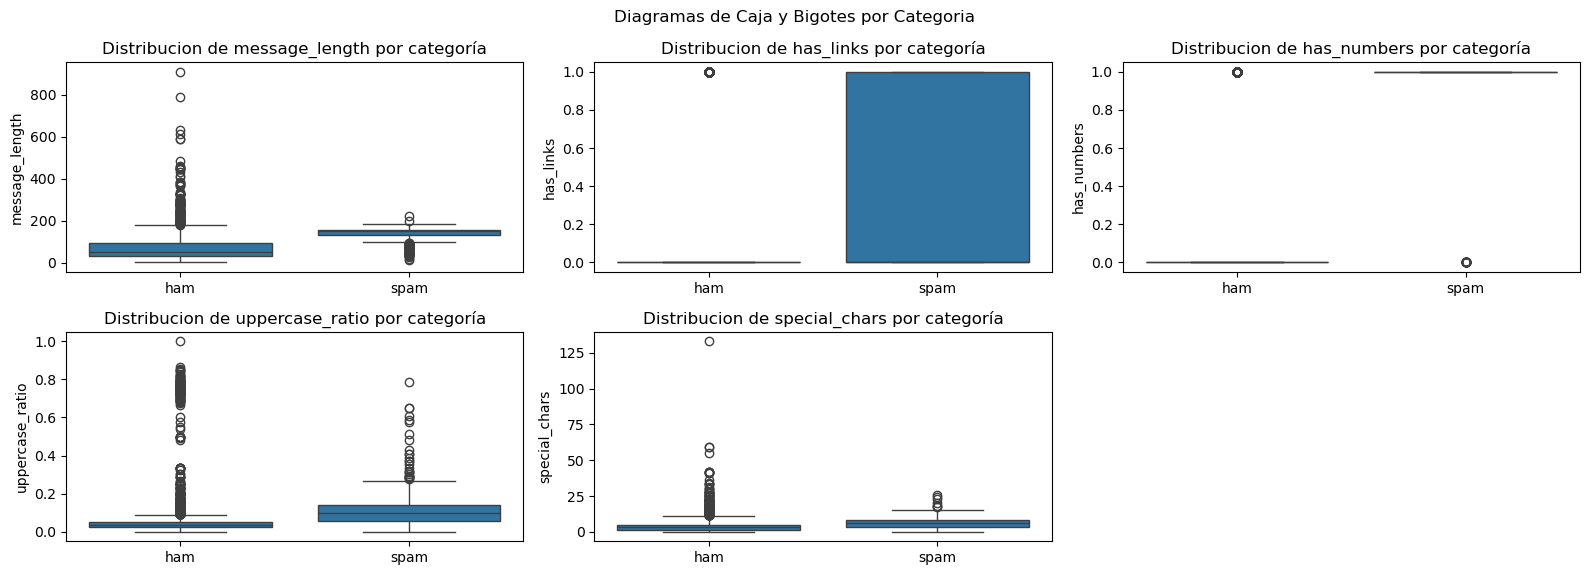

In [ ]:
# Excluimos la columna is_spam ya que es nuestra variable objetivo
features_to_plot = [col for col in num_cols if col != 'is_spam']

plt.figure(figsize=(16, 8))
for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    sb.boxplot(x='category', y=feature, data=df_clean)
    plt.title(f'Distribucion de {feature} por categoría')
    plt.xlabel('')
    plt.ylabel(feature)

plt.tight_layout()
plt.suptitle('Diagramas de Caja y Bigotes por Categoria', y=1.02)
plt.show()

# Matriz de Correlación:

- Mostrará qué características están correlacionadas entre sí

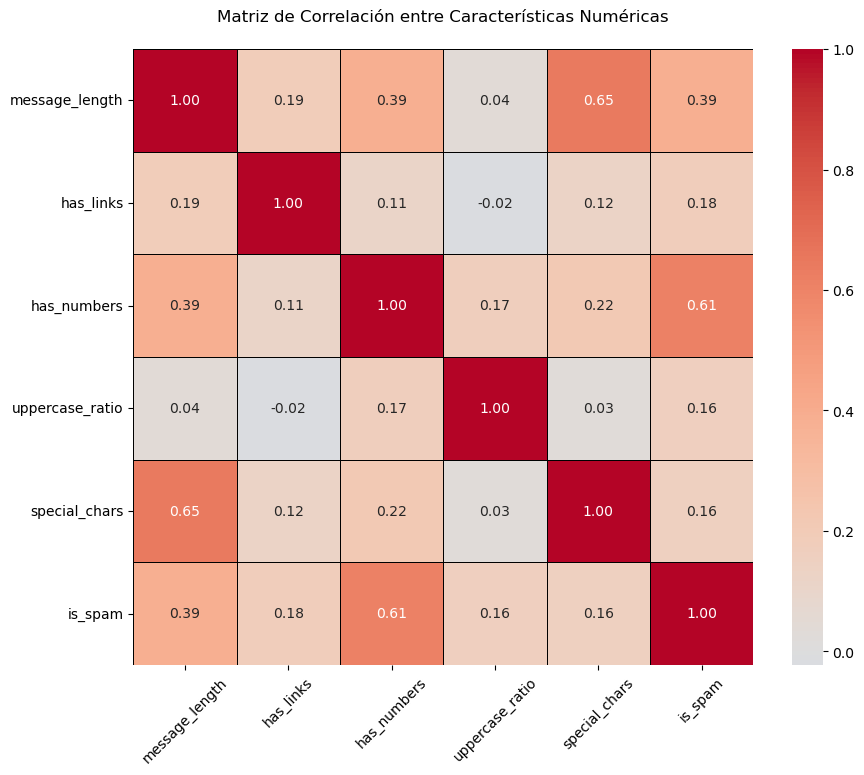

In [ ]:
# Calcular matriz de correlación
corr_matrix = df_clean[num_cols].corr()

# Visualizar matriz de correlación
plt.figure(figsize=(10, 8))
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, linecolor='black')
plt.title('Matriz de Correlación entre Características Numéricas', pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

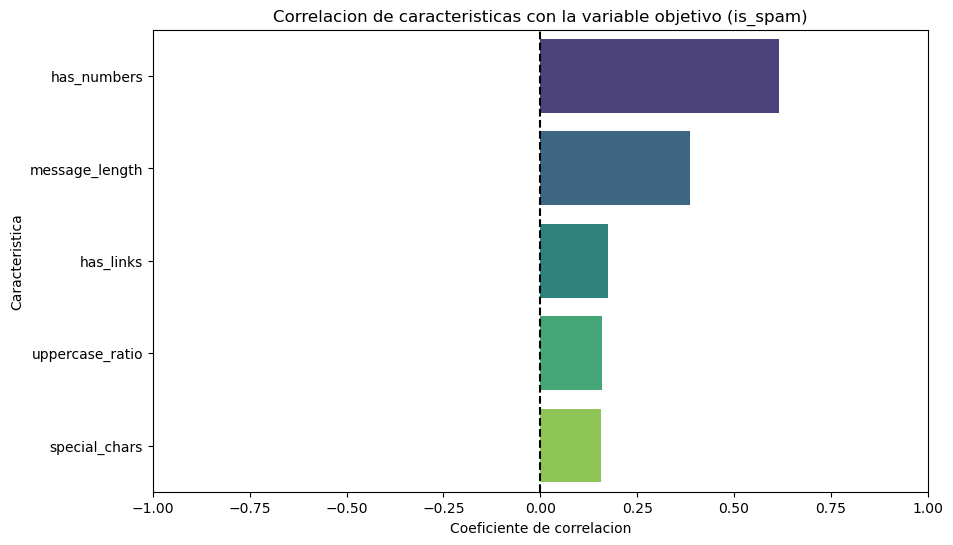

In [ ]:
# Correlación con la variable objetivo

# Mayor visualizacion predictivo respecto a la variable objetivo is_spam (si un mensaje es spam o no).
spam_corr = df_clean[num_cols].corr()['is_spam'].sort_values(ascending=False)

# Excluir la correlación consigo misma
spam_corr = spam_corr.drop('is_spam')

# Visualizar correlaciones
plt.figure(figsize=(10, 6))
sb.barplot(x=spam_corr.values, y=spam_corr.index, palette='viridis')
plt.title('Correlacion de caracteristicas con la variable objetivo (is_spam)')
plt.xlabel('Coeficiente de correlacion')
plt.ylabel('Caracteristica')
plt.xlim(-1, 1)
plt.axvline(0, color='black', linestyle='--')
plt.show()

In [ ]:
# Pipeline de preprocesamiento de datos

# Transformacion para las variables categóricas (object)
# Transformacion para las variables numéricas (int64, float64)

cat_col = df_clean.select_dtypes(include=['object']).columns.to_list()
cat_col.remove('message')

num_col = df_clean.select_dtypes(include=['int64', 'float64']).columns.to_list()


In [ ]:
# Ejecutamos el pipeline

cat_transformer = Pipeline(steps = [('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))])
num_transformer = Pipeline(steps = [('scaler', MinMaxScaler())])
preprocessor = ColumnTransformer(transformers = [('numeric', num_transformer, num_col), ('categorical', cat_transformer, cat_col)])
preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('scaler', MinMaxScaler())]),
                                 ['message_length', 'has_links', 'has_numbers',
                                  'uppercase_ratio', 'special_chars',
                                  'is_spam']),
                                ('categorical',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['category'])])

In [ ]:
# Aqui aplicamos la transformación y reconstruimos un DataFrame limpio y listo para modelos
data_pre = preprocessor.fit_transform(df_clean)
cod_cat = preprocessor.named_transformers_['categorical']['encoder'].get_feature_names_out(cat_col)
labels = np.concatenate([num_col, cod_cat])
data_pro = pd.DataFrame(data_pre, columns=labels)
data_pro

,message_length,has_links,has_numbers,uppercase_ratio,special_chars,is_spam,category_ham,category_spam
0,0.120044,0.0,0.0,0.027027,0.067669,0.0,1.0,0.0
1,0.029736,0.0,0.0,0.068966,0.045113,0.0,1.0,0.0
2,0.168502,1.0,1.0,0.064516,0.045113,1.0,0.0,1.0
3,0.051762,0.0,0.0,0.040816,0.045113,0.0,1.0,0.0
4,0.064978,0.0,0.0,0.032787,0.015038,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
5567,0.175110,0.0,1.0,0.055901,0.067669,1.0,0.0,1.0
5568,0.038546,0.0,0.0,0.054054,0.015038,0.0,1.0,0.0
5569,0.060573,0.0,0.0,0.035088,0.052632,0.0,1.0,0.0
5570,0.135463,0.0,0.0,0.016000,0.007519,0.0,1.0,0.0


In [ ]:
# Variables numéricas que se usaran como predictores
numerical_features = ['message_length', 'has_numbers',
                      'has_links', 'uppercase_ratio', 'special_chars']

print(f"Características numéricas utilizadas: {numerical_features}")


Características numéricas utilizadas: ['message_length', 'has_numbers', 'has_links', 'uppercase_ratio', 'special_chars']


# DIVISIÓN DE DATOS EN ENTRENAMIENTO Y PRUEBA

In [ ]:
X = data_pro[numerical_features].values

# Variable objetivo
y = data_pro['is_spam'].values

In [ ]:
# y ya está en formato binario, perfecto para clasificación binaria.
y = df_clean['category'].map({'ham': 0, 'spam': 1}).values

print("Variable objetivo (y):", np.unique(y))

Variable objetivo (y): [0 1]


In [ ]:
# División usando las características numéricas (X) y objetivo (y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,  # Usar nuestras variables X e y definidas arriba
    test_size=0.2,
    random_state=42,
)

# Modelos

In [ ]:
# Importaciones necesarias para los modelos

from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sb

# FUNCIÓN DE EVALUACIÓN DE MODELOS

    Función para evaluar el rendimiento de los modelos de clasificación
    
    Parámetros:
    
    - modelo: modelo entrenado
    - X_train, X_test: datos de entrenamiento y prueba (características numéricas)
    - y_train, y_test: etiquetas de entrenamiento y prueba
    - nombre_modelo: nombre del modelo para mostrar en resultados

In [ ]:
def evaluar_modelo(modelo, X_train, X_test, y_train, y_test, nombre_modelo):

    print(f"\nEVALUACIÓN DEL MODELO: {nombre_modelo}")

    # Predicciones
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    # Métricas de rendimiento
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_train = f1_score(y_train, y_pred_train)
    f1_test = f1_score(y_test, y_pred_test)
    recall_test = recall_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test)


    print(f"Accuracy Entrenamiento: {acc_train:.4f}")
    print(f"Accuracy Prueba: {acc_test:.4f}")
    print(f"F1-Score Entrenamiento: {f1_train:.4f}")
    print(f"F1-Score Prueba: {f1_test:.4f}")
    print(f"Recall Prueba: {recall_test:.4f}")
    print(f"Precision Prueba: {precision_test:.4f}")


    # Detectar sobreajuste
    if acc_train - acc_test > 0.1:
        print("Posible sobreajuste detectado")

    print(f"\nReporte de Clasificación (Conjunto de Prueba):")
    print(classification_report(y_test, y_pred_test,
                              target_names=['Ham', 'Spam']))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(6, 4))
    sb.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'])
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.ylabel('Valores Reales')
    plt.xlabel('Predicciones')
    plt.show()

    return acc_test, f1_test, recall_test, precision_test



EVALUACIÓN DEL MODELO: Random Forest
Accuracy Entrenamiento: 0.9984
Accuracy Prueba: 0.9641
F1-Score Entrenamiento: 0.9941
F1-Score Prueba: 0.8592
Recall Prueba: 0.8133
Precision Prueba: 0.9104

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98       965
        Spam       0.91      0.81      0.86       150

    accuracy                           0.96      1115
   macro avg       0.94      0.90      0.92      1115
weighted avg       0.96      0.96      0.96      1115



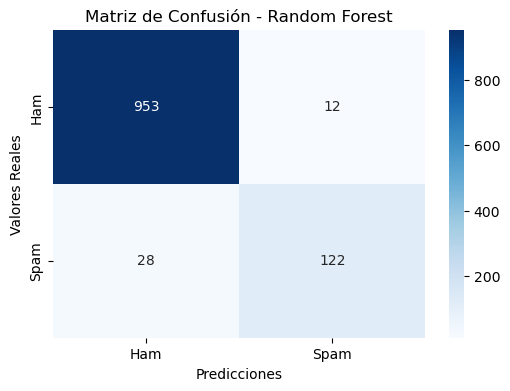

(0.9641255605381166,
 0.8591549295774648,
 0.8133333333333334,
 0.9104477611940298)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar el modelo
modelo = RandomForestClassifier()
modelo.fit(X_train, y_train)

# Evaluar
evaluar_modelo(modelo, X_train, X_test, y_train, y_test, "Random Forest")

# MODELO 1: REGRESIÓN LOGÍSTICA

**Nota:**

- Empezamos con Regresión Logística porque es simple, interpretable y efectivo

- Funciona bien con características numéricas como las que hemos creado


**Características:**

- Clasificador lineal robusto
- Proporciona probabilidades de predicción
- Funciona bien con alta dimensionalidad
- Interpretable y estable

MODELO 1: REGRESIÓN LOGÍSTICA

EVALUACIÓN DEL MODELO: Regresión Logística
Accuracy Entrenamiento: 0.8966
Accuracy Prueba: 0.8915
F1-Score Entrenamiento: 0.5404
F1-Score Prueba: 0.4895
Recall Prueba: 0.3867
Precision Prueba: 0.6667

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

         Ham       0.91      0.97      0.94       965
        Spam       0.67      0.39      0.49       150

    accuracy                           0.89      1115
   macro avg       0.79      0.68      0.71      1115
weighted avg       0.88      0.89      0.88      1115



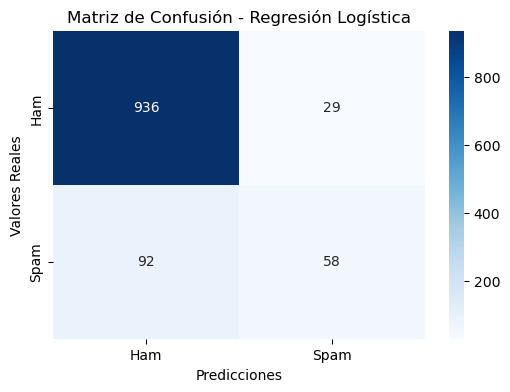

(0.8914798206278027,
 0.48945147679324896,
 0.38666666666666666,
 0.6666666666666666)

In [ ]:
from sklearn.linear_model import LogisticRegression

print("MODELO 1: REGRESIÓN LOGÍSTICA")

# Crear y entrenar el modelo
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0  # Parámetro de regularización
)
lr_model.fit(X_train, y_train)

# Evaluar el modelo
evaluar_modelo(
    lr_model,
    X_train,
    X_test,
    y_train,
    y_test,
    "Regresión Logística"
)

# MODELO 2: NAIVE BAYES MULTINOMIAL

**Nota:**

- Naive Bayes es especialmente efectivo para clasificación de texto

**Características:**

- Muy efectivo para clasificación de texto
- Rápido entrenamiento y predicción
- Funciona bien con datasets pequeños
- Asume independencia entre palabras

MODELO 2: NAIVE BAYES MULTINOMIAL

EVALUACIÓN DEL MODELO: Naive Bayes
Accuracy Entrenamiento: 0.8661
Accuracy Prueba: 0.8655
F1-Score Entrenamiento: 0.0000
F1-Score Prueba: 0.0000
Recall Prueba: 0.0000
Precision Prueba: 0.0000

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       965
        Spam       0.00      0.00      0.00       150

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



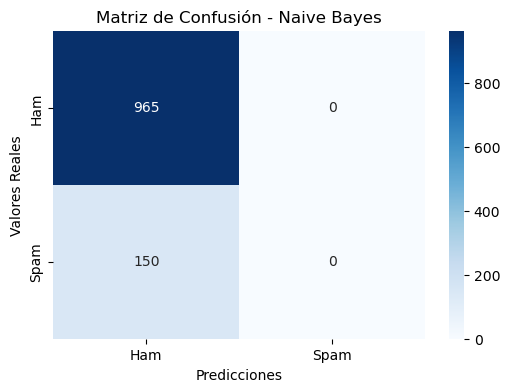

(0.8654708520179372, 0.0, 0.0, 0.0)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

print("MODELO 2: NAIVE BAYES MULTINOMIAL")

# Crear y entrenar el modelo
nb_model = MultinomialNB(alpha=1.0)  # alpha es el parámetro de suavizado
nb_model.fit(X_train, y_train)

# Evaluar el modelo
evaluar_modelo(nb_model, X_train, X_test,
                               y_train, y_test, "Naive Bayes")

# MODELO 3: RANDOM FOREST

**Nota:**

- Random Forest es un ensemble de árboles de decisión
- Menos efectivo con texto de alta dimensionalidad pero robusto
- Puede manejar tanto características numéricas mixtas como de texto


**Características:**

- Ensemble de múltiples árboles de decisión
- Robusto contra sobreajuste
- Puede manejar características mixtas
- Proporciona importancia de características

MODELO 3: RANDOM FOREST

EVALUACIÓN DEL MODELO: Random Forest
Accuracy Entrenamiento: 0.9870
Accuracy Prueba: 0.9650
F1-Score Entrenamiento: 0.9514
F1-Score Prueba: 0.8632
Recall Prueba: 0.8200
Precision Prueba: 0.9111

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98       965
        Spam       0.91      0.82      0.86       150

    accuracy                           0.97      1115
   macro avg       0.94      0.90      0.92      1115
weighted avg       0.96      0.97      0.96      1115



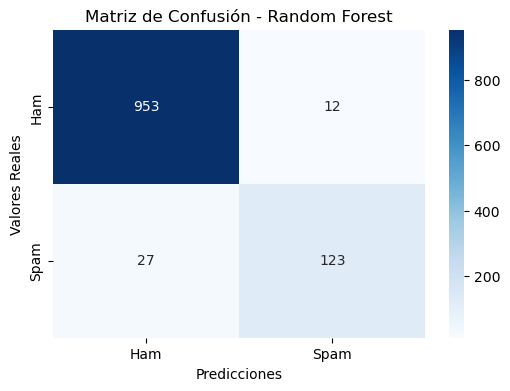

(0.9650224215246637, 0.8631578947368421, 0.82, 0.9111111111111111)

In [ ]:
print("MODELO 3: RANDOM FOREST")

# Para Random Forest, convertimos la matriz sparse a densa
# En datasets grandes, esto podría causar problemas de memoria

# X_train_dense = X_train.toarray()
# X_test_dense = X_test.toarray()
# Nota: Esto causaria un error porque estamos usando X_train y X_test, que ya no son matrices dispersas (sparse), sino arreglos NumPy, por eso no se puede usar toarray().

# Crear y entrenar el modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,  # Limitar profundidad para evitar sobreajuste
    random_state=42,
    n_jobs=-1  # Usar todos los procesadores disponibles
)
rf_model.fit(X_train, y_train)

# Evaluar el modelo
evaluar_modelo(rf_model, X_train, X_test,
                               y_train, y_test, "Random Forest")

# MODELO 4: ÁRBOL DE DECISIÓN

**Nota:**

- Árbol de decisión simple, interpretable pero propenso al sobreajuste
- Útil para entender las reglas de clasificación


**Características:**

- Muy interpretable
- Reglas de clasificación claras
- Propenso al sobreajuste
- Funciona bien con características mixtas

MODELO 4: ÁRBOL DE DECISIÓN

EVALUACIÓN DEL MODELO: Árbol de Decisión
Accuracy Entrenamiento: 0.9610
Accuracy Prueba: 0.9596
F1-Score Entrenamiento: 0.8500
F1-Score Prueba: 0.8432
Recall Prueba: 0.8067
Precision Prueba: 0.8832

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

         Ham       0.97      0.98      0.98       965
        Spam       0.88      0.81      0.84       150

    accuracy                           0.96      1115
   macro avg       0.93      0.90      0.91      1115
weighted avg       0.96      0.96      0.96      1115



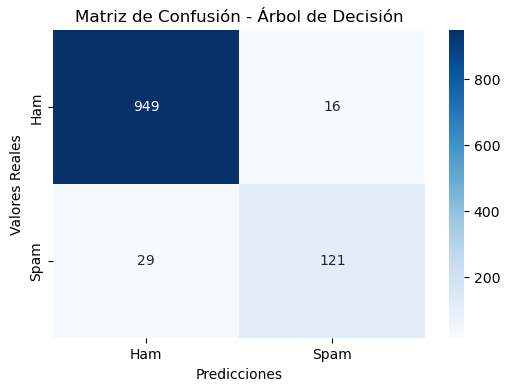

(0.9596412556053812,
 0.8432055749128919,
 0.8066666666666666,
 0.8832116788321168)

In [ ]:
print("MODELO 4: ÁRBOL DE DECISIÓN")

# Crear y entrenar el modelo
dt_model = DecisionTreeClassifier(
    max_depth=5,  # Limitar profundidad
    min_samples_split=20,  # Minimo de muestras para dividir
    random_state=42
)
dt_model.fit(X_train, y_train)

# Evaluar el modelo
evaluar_modelo(dt_model, X_train, X_test,
                               y_train, y_test, "Árbol de Decisión")

# MODELO 5: XGBClassifier

**Nota:**

- Sirve para resolver problemas de clasificación (por ejemplo, detectar si un mensaje es spam o no, si un cliente comprará o no, si una transacción es fraude o no).


**Características:**

- Muy potente y eficiente
- Usa boosting de gradiente sobre árboles de decisión
- Maneja tanto variables numéricas como categóricas
- Menos propenso al sobreajuste que un árbol de decisión simple
- Entrenamiento rápido y optimizado

In [ ]:
!pip3 install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.6 MB/s eta 0:00:00


MODELO 5: XGBClassifier

EVALUACIÓN DEL MODELO: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)
Accuracy Entrenamiento: 0.9984
Accuracy Prueba: 0.9641
F1-Score Entrenamiento: 0.9941
F1-Score Prueba: 0.8592
Recall Prueba: 0.8133
Precision Prueba: 0.9104

Reporte de Cla

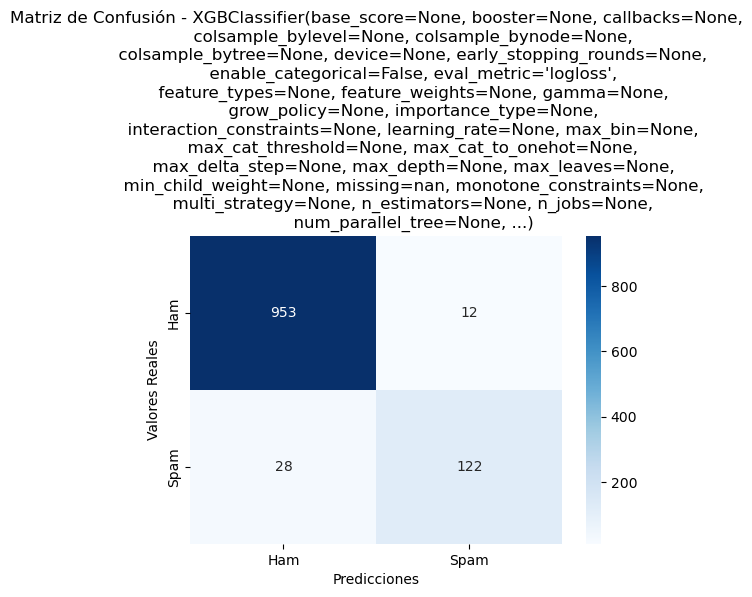

(0.9641255605381166,
 0.8591549295774648,
 0.8133333333333334,
 0.9104477611940298)

In [ ]:
print("MODELO 5: XGBClassifier")

from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
evaluar_modelo(modelo, X_train, X_test, y_train, y_test, xgb)

Support - Cantidad de muestras reales de la clase

Precision - mide la exactitud de las predicciones positivas del modelo. Es decir, de todas las veces que el modelo predijo un caso positivo, cuántas veces acertó. un valor alto indica que el modelo el bueno prediciendo

Recall - mide la capacidad del modelo para captar todos los casos realmente positivos, es decir que se enfoca en cuántos verdaderos positivos fue capaz de encontrar el modelo entre todos los que realmente lo eran, incluyendo aquellos que no logró detectar (los falsos negativos). un valor alto indica que el modelo es bueno buscando los valores reales

los verdaderos positivos (prediccion correcta en un caso positivo) los falsos positivos (equivocacion del modelo) los falsos negativos (error del modelo) y los verdaderos negativos (prediccion correcta en un caso negativo)


F1-Score - Promedio entre la presicion y el recall, entre mas alto mejor el modelo (parametro que usaremos para seleccionar el mejor modelo)

# Conclusion

Para nuestro problema de clasificación desbalanceado como el de detección de spam, el F1-Score es más representativo que el Accuracy

In [ ]:
# Hiperparametros
from sklearn.model_selection import GridSearchCV
parametros = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
# Modelos
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [ ]:
# Validación cruzada (F1-score)
resultados = {}
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='f1')
    resultados[nombre] = scores.mean()
    print(f"{nombre}: F1 promedio = {scores.mean():.4f}")

Logistic Regression: F1 promedio = 0.4942
Naive Bayes: F1 promedio = 0.0000
Random Forest: F1 promedio = 0.8572
Decision Tree: F1 promedio = 0.8042
XGBoost: F1 promedio = 0.8381


In [ ]:
import pandas as pd

# Se crea el DataFrame con F1-Scores
f1_data = {
   'Model': ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'Decision Tree', 'XGBoost'],
    'F1_Score': [0.4942, 0.0000, 0.8572, 0.8042, 0.8381]
}

f1_df = pd.DataFrame(f1_data)
print(f1_df)


                 Model  F1_Score
0  Logistic Regression    0.4942
1          Naive Bayes    0.0000
2        Random Forest    0.8572
3        Decision Tree    0.8042
4              XGBoost    0.8381


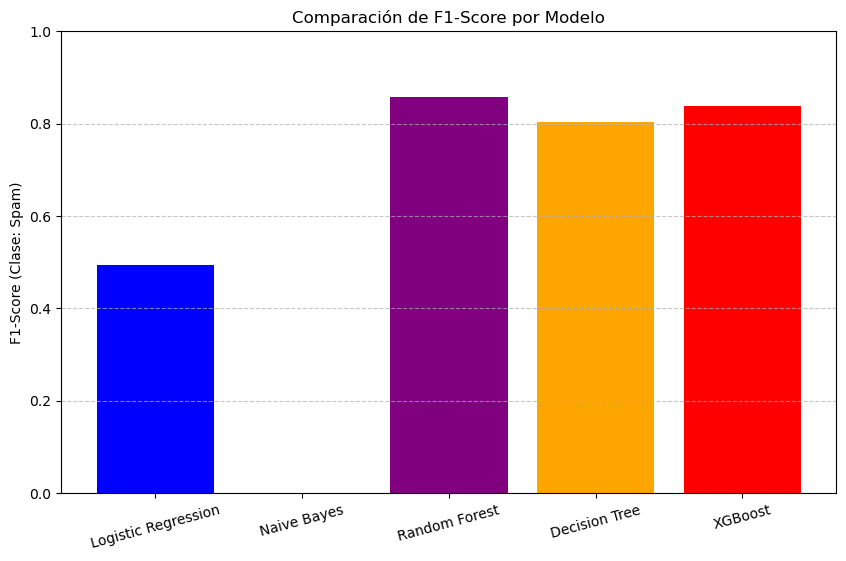

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(f1_df['Model'], f1_df['F1_Score'], color=['blue', 'green', 'purple', 'orange', 'red'])
plt.title('Comparación de F1-Score por Modelo')
plt.ylabel('F1-Score (Clase: Spam)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)
plt.show()


In [ ]:
# Se escoje el mejor modelo
from sklearn.model_selection import cross_val_score

for nombre, modelo in modelos.items():
    score = cross_val_score(modelo, X_train, y_train, cv=5, scoring='f1')
    print(f"{nombre}: F1 promedio = {score.mean():.4f}")


Logistic Regression: F1 promedio = 0.4942
Naive Bayes: F1 promedio = 0.0000
Random Forest: F1 promedio = 0.8572
Decision Tree: F1 promedio = 0.8042
XGBoost: F1 promedio = 0.8381


In [ ]:
# Modelo seleccionado

modelo = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator = modelo, param_grid=parametros, cv=5, scoring='f1')

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [10, 20], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [ ]:
# Mejores hiperparámetros encontrados
print("Mejores parámetros encontrados:", grid_search.best_params_)
print("Mejor F1-score:", grid_search.best_score_)


Mejores parámetros encontrados: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejor F1-score: 0.857241396938399



EVALUACIÓN DEL MODELO: Random Forest Optimizado
Accuracy Entrenamiento: 0.9984
Accuracy Prueba: 0.9641
F1-Score Entrenamiento: 0.9941
F1-Score Prueba: 0.8582
Recall Prueba: 0.8067
Precision Prueba: 0.9167

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98       965
        Spam       0.92      0.81      0.86       150

    accuracy                           0.96      1115
   macro avg       0.94      0.90      0.92      1115
weighted avg       0.96      0.96      0.96      1115



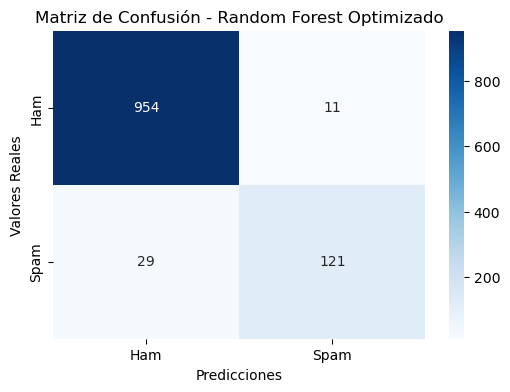

(0.9641255605381166,
 0.8581560283687943,
 0.8066666666666666,
 0.9166666666666666)

In [ ]:
# Evaluacion
mejor_modelo = grid_search.best_estimator_
evaluar_modelo(mejor_modelo, X_train, X_test, y_train, y_test, "Random Forest Optimizado")


# **Conclusiones**

# **Analisis de los modelos con mejores resultados**

**Random Forest**

- **F1 Score:** 0.8572

- Muy buen equilibrio entre precisión y recall.

- Robusto a datos ruidosos.

**Nota:** Puede ser más costoso computacionalmente, pero es estable y confiable.


**XGBoost**

**F1 Score:** 0.8381

- Rendimiento competitivo.

- Escala bien con datos más grandes.

**Nota:** Ideal si tienes necesidad de hacer ajustes finos (tuning de hiperparámetros).

- Puede requerir más monitoreo por su complejidad.


**Decision Tree**

**F1 Score:** 0.8042

- Simples de interpretar y depurar.

**Nota:** Menos generalizables que los anteriores.
- Útil si necesitas explicabilidad rápida o el dataset es pequeño.


# **Analisis de los modelos con resultados pobres**

**Naive Bayes**

**F1 Score:** 0.0000

- Claramente no está funcionando bien. Posiblemente por mala distribución de clases o falta de ingeniería de características adecuada para este modelo.


**Logistic Regression**

**F1 Score:** 0.4942

- Aunque no es tan bajo, es insuficiente para tareas como detección de spam, donde el recall y precisión son clave.

- Podría usarse si el dataset se ajusta mejor (p. ej., con mejores embeddings o normalización), pero no en el estado actual.


# **¿Usaria estos modelos en un entorno de producción?**

- Sí, usariamos Random Forest o XGBoost en producción en este caso, siempre que se monitoreen correctamente y se validen con datos reales.

- Los modelos de Naive Bayes y Logistic Regression, en su estado actual, no son recomendables para producción.

l que responde directamente a qué métricas deberías priorizar y por qué, especialmente si estás pensando en llevar un modelo de detección de spam a producción:

**Finalmente**, en un sistema de clasificación de spam, nos debemos enfocar en maximizar el F1-Score, con especial atención al recall y precision de la clase SPAM.

Esto asegura que el sistema detecte la mayor cantidad de spam posible sin perjudicar mensajes legítimos.

# Referencias

- https://www.kaggle.com/code/asifaparveenmabscds/sms-spam-detection-using-ml